#**"Educational machine-learning project based on the Pima Indians Diabetes Dataset."**

Import Libraries

In [1]:
from pickleshare import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mariamelghareeb/diabeties-prediction")

print("Path to dataset files:", path)

100%|██████████| 734k/734k [00:00<00:00, 824kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mariamelghareeb/diabeties-prediction/versions/1


In [3]:
db=pd.read_csv(f'{path}/diabetes_prediction_dataset.csv')
db.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [4]:
db.shape

(100000, 9)

In [5]:
db.isna().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [6]:
db.duplicated().sum()

np.int64(3854)

In [7]:
db=db.drop_duplicates()

In [8]:
db.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96146 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               96146 non-null  object 
 1   age                  96146 non-null  float64
 2   hypertension         96146 non-null  int64  
 3   heart_disease        96146 non-null  int64  
 4   smoking_history      96146 non-null  object 
 5   bmi                  96146 non-null  float64
 6   HbA1c_level          96146 non-null  float64
 7   blood_glucose_level  96146 non-null  int64  
 8   diabetes             96146 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 7.3+ MB


In [9]:
db.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000
mean,41.794326,0.077601,0.040803,27.321461,5.532609,138.218231,0.088220
std,22.462948,0.267544,0.197833,6.767716,1.073232,40.909771,0.283616
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.400000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,59.000000,0.000000,0.000000,29.860000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


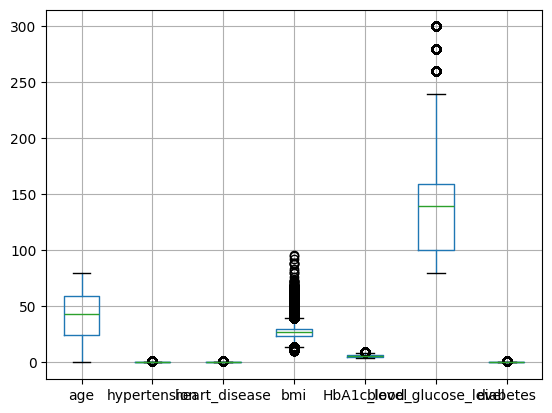

In [10]:
db.boxplot()
plt.show()

In [11]:
#to remove outliers
#BMI
q1=db['bmi'].quantile(0.25)
q3=db['bmi'].quantile(0.75)
iqr= q3-q1
print('IQR is', iqr)
lower=q1-1.5*iqr
upper= q3+1.5*iqr
print('Lower →',lower)
print('Upper →',upper)
db=db[(db['bmi']>lower)&(db['bmi']<upper)]
print('Outliers are removed')

IQR is 6.460000000000001
Lower → 13.709999999999997
Upper → 39.55
Outliers are removed


In [12]:
#to remove outliers
#Glucose
q1=db['blood_glucose_level'].quantile(0.25)
q3=db['blood_glucose_level'].quantile(0.75)
iqr= q3-q1
print('IQR is', iqr)
lower=q1-1.5*iqr
upper= q3+1.5*iqr
print('Lower →',lower)
print('Upper →',upper)
db=db[(db['blood_glucose_level']>lower)&(db['blood_glucose_level']<upper)]
print('Outliers are removed')

IQR is 59.0
Lower → 11.5
Upper → 247.5
Outliers are removed


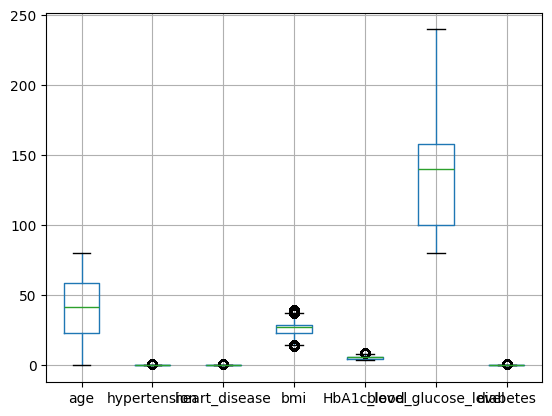

In [13]:
db.boxplot()
plt.show()

In [14]:
db.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

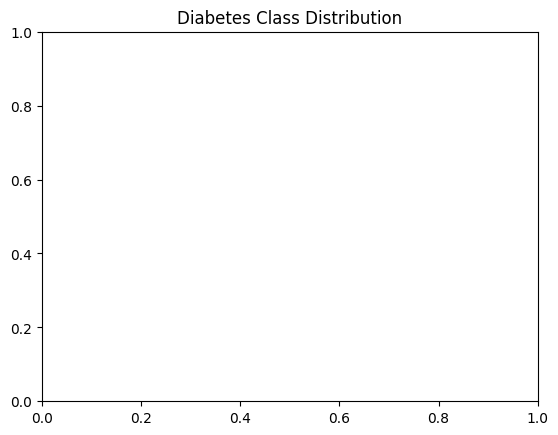

In [15]:
#Diabetes Class Distribution
#sns.countplot(data = db, x='diabetes')
plt.title('Diabetes Class Distribution')
plt.show()

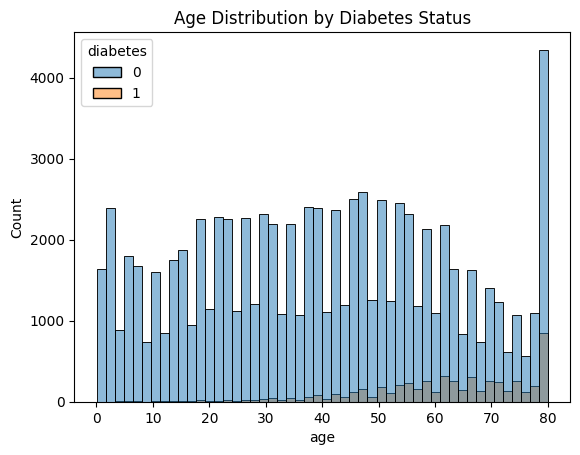

In [16]:
#Age Distribution for Diabetes and Non-Diabetes
sns.histplot(data=db,x='age', hue='diabetes')
plt.title('Age Distribution by Diabetes Status')
plt.show()

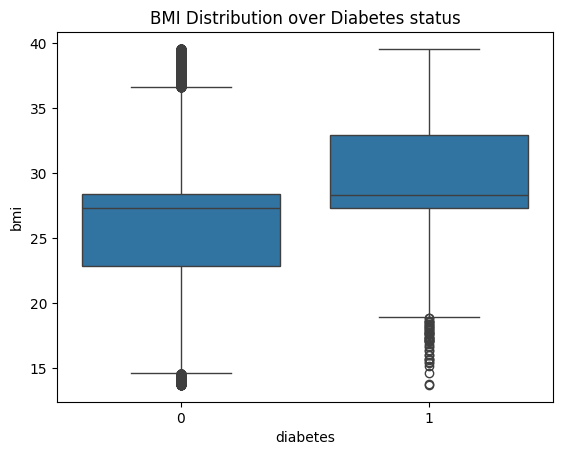

In [17]:
#BMI Distribution over Diabetes status
sns.boxplot(data = db, x='diabetes',y = 'bmi')
plt.title('BMI Distribution over Diabetes status')
plt.show()

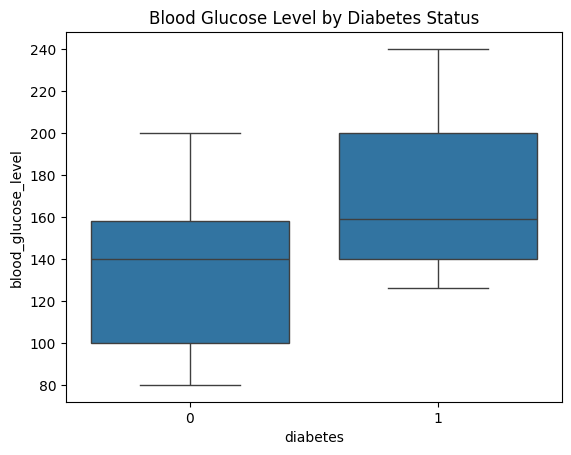

In [18]:
#Blood Glucose Level diatribution for diabetes status
sns.boxplot(data = db, x='diabetes', y='blood_glucose_level')
plt.title('Blood Glucose Level by Diabetes Status')
plt.show()

In [19]:
db.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

In [20]:
db=pd.get_dummies(db, columns=['gender', 'smoking_history'])


In [21]:
x=db.drop('diabetes', axis=1)
y=db['diabetes']

In [22]:
x_train, x_test, y_train, y_test=train_test_split(x, y , test_size=0.2, random_state=48, stratify=y)

In [23]:
db.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Female,gender_Male,gender_Other,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,True,False,False,False,False,False,False,True,False
1,54.0,0,0,27.32,6.6,80,0,True,False,False,True,False,False,False,False,False
2,28.0,0,0,27.32,5.7,158,0,False,True,False,False,False,False,False,True,False
3,36.0,0,0,23.45,5.0,155,0,True,False,False,False,True,False,False,False,False
4,76.0,1,1,20.14,4.8,155,0,False,True,False,False,True,False,False,False,False


In [24]:
model=DecisionTreeClassifier(
     criterion='gini',
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features=None,
    class_weight='balanced',
    random_state=42
)
model.fit(x_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5, min_samples_leaf=5,
                       min_samples_split=10, random_state=42)

In [25]:
predict= model.predict(x_test)
predict

array([1, 0, 0, ..., 1, 1, 1])

In [26]:
cls=classification_report(y_test, predict)
print(cls)

              precision    recall  f1-score   support

           0       0.99      0.85      0.92     16715
           1       0.29      0.90      0.44      1099

    accuracy                           0.86     17814
   macro avg       0.64      0.88      0.68     17814
weighted avg       0.95      0.86      0.89     17814



To Select Best parameters to maximize Precision and recall

In [27]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6, 7, 8, 10],
    'min_samples_split': [2, 5, 10, 20, 50],
    'min_samples_leaf': [1, 2, 5, 10, 20],
    'class_weight': [None, 'balanced']
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=params,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid.fit(x_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

Best parameters: {'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 20, 'min_samples_split': 50}
Best CV F1: 0.7258015144269979


In [28]:
best_model = grid.best_estimator_

predict = best_model.predict(x_test)

print(classification_report(y_test, predict))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99     16715
           1       0.97      0.58      0.73      1099

    accuracy                           0.97     17814
   macro avg       0.97      0.79      0.86     17814
weighted avg       0.97      0.97      0.97     17814



In [29]:
pickle.dump(best_model, open("Diabetes-Prediction-Project-Model.pkl",'wb'))
print('pkl file is created successfully')

pkl file is created successfully


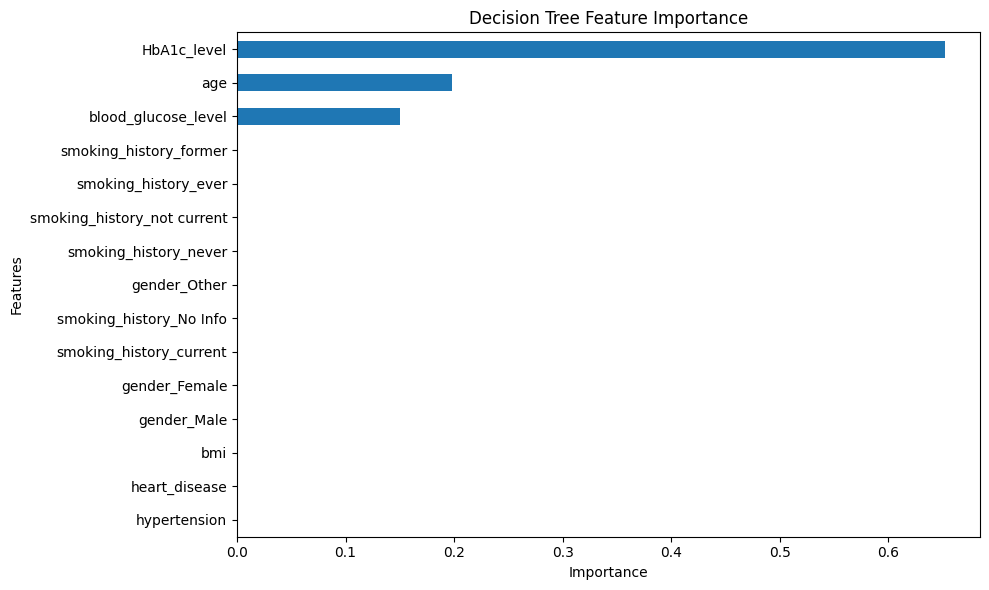

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importance = pd.Series(
    model.feature_importances_,
    index=x_train.columns
).sort_values(ascending=True)

# Plot
plt.figure(figsize=(10, 6))

importance.plot(kind='barh')

plt.title('Decision Tree Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Features')

plt.tight_layout()
plt.show()